## Data Profiling and Structural Assessment

We first want to perform some data profiling on the datasets to understand their structure, data quality, and compatibility.

This step helps us:
- assess completeness and integrity,
- identify cleaning requirements,
- compare schemas across datasets,
- and justify why model-based enrichment is used instead of direct joins.

In [2]:
import os
print(os.getcwd())

c:\Users\wayne\OneDrive\Documents\GitHub\sc3021-projects


In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

DATA_DIR = "datasets"

DATASETS = {
    "ds1_main": os.path.join(DATA_DIR, "ds1_main.csv"),
    "ds2_lifestyle": os.path.join(DATA_DIR, "ds2_lifestyle.csv"),
    "ds3_social-media": os.path.join(DATA_DIR, "ds3_social-media.csv"),
    "ds4_digital-literacy": os.path.join(DATA_DIR, "ds4_digital-literacy.csv"),
    "ds5_social-wellbeing": os.path.join(DATA_DIR, "ds5_social-wellbeing.csv"),
}

dfs = {}

for name, path in DATASETS.items():
    dfs[name] = pd.read_csv(path)

print("Loaded datasets:", list(dfs.keys()))

C:\Users\wayne\AppData\Local\Temp\ipykernel_30556\2360983619.py:23: DtypeWarning: Columns (8,9,10,21,22,23,75,104,106,107,108,117,118,240,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,281,282,283,284,285,286,287,288,289,290,291,292,294,296,299,308,309,315,316,317,324,393,395,396,397,398,409,410,411,414,421,422,426,427,437,441,445,449,453,457,461,465,469,473,477,485,497,501,505,509,513,517,521,529,533,537,541,545,557,561,565,569,573,577,581,585,597,605,609,613,617,641,645,653,657,661,665,669,673,677,681,685,689,693,697,701,705,709,713,717,721,725,729,733,737,741,745,749,753,757,761,765,769,773,777,781,785,789,793,797,801,805,809,813,821,829,833,837,841,845,849,896,898,899,900,901,903,904,907,908,909,917,918,919,920,921,922,923,924,925,926,927,937,938,939,940,941,942,943,944,945,946,947,948,949,950,951,952,953,954,955,956,958,960,962,964,966,968,970,972,974,976,978,980,982,984,986,988,990,992,994,996,998,1000,1002,1004,1006,1008,1010,1012,1286,1304) 

Loaded datasets: ['ds1_main', 'ds2_lifestyle', 'ds3_social-media', 'ds4_digital-literacy', 'ds5_social-wellbeing']


### 1. Profiling helper functions

In order to assess the datasets, we needed to establish some metadata.

We defined a set of profiling functions to compare all the datasets in systematic and consistent manner rather than profiling them in an ad hoc way.

In [4]:
def basic_overview(df: pd.DataFrame) -> dict:
    n_rows, n_cols = df.shape
    dtypes = df.dtypes.astype(str)
    type_counts = dtypes.value_counts().to_dict()

    n_numeric = df.select_dtypes(include=[np.number]).shape[1]
    n_categorical = df.select_dtypes(include=["object", "category", "bool"]).shape[1]

    return {
        "rows": n_rows,
        "cols": n_cols,
        "numeric_cols": n_numeric,
        "categorical_cols": n_categorical,
        "dtype_counts": type_counts
    }

def missing_profile(df: pd.DataFrame) -> pd.DataFrame:
    miss_cnt = df.isna().sum()
    miss_pct = (miss_cnt / len(df) * 100).round(2)
    out = pd.DataFrame({"missing_count": miss_cnt, "missing_pct": miss_pct})
    return out.sort_values(["missing_pct", "missing_count"], ascending=False)

def duplicate_profile(df: pd.DataFrame) -> dict:
    dup_rows = int(df.duplicated().sum())
    id_like = [c for c in df.columns if re.search(r"(?:^id$|_id$|^student_id$|^user_id$)", c)]
    id_dup_info = {}
    for c in id_like:
        if df[c].notna().sum() > 0:
            id_dup_info[c] = int(df[c].duplicated().sum())
    return {
        "duplicate_rows": dup_rows,
        "id_like_cols": id_like,
        "id_like_duplicate_counts": id_dup_info
    }

def numeric_profile(df: pd.DataFrame) -> pd.DataFrame:
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] == 0:
        return pd.DataFrame()
    desc = num.describe().T
    desc["skew"] = num.skew(numeric_only=True)
    return desc.sort_values("std", ascending=False)

def categorical_profile(df: pd.DataFrame, top_k: int = 5) -> dict:
    cat = df.select_dtypes(include=["object", "category", "bool"])
    profiles = {}
    for c in cat.columns:
        vc = df[c].astype("object").value_counts(dropna=False)
        total = vc.sum()
        top = (vc.head(top_k) / total * 100).round(2)
        profiles[c] = {
            "unique_count": int(df[c].nunique(dropna=True)),
            "top_values_pct": top.to_frame("pct").reset_index().rename(columns={"index": c}),
        }
    return profiles

### 2. Dataset Overview

We started by examining the size and structure of each dataset, detailing the number of rows, columns and variable types, providing a quick summary of the structure and nature of the datasets

In [5]:
overview_rows = []

for name, df in dfs.items():
    ov = basic_overview(df)
    ov["dataset"] = name
    overview_rows.append(ov)

overview_df = pd.DataFrame(overview_rows)
display(overview_df[["dataset", "rows", "cols", "numeric_cols", "categorical_cols", "dtype_counts"]])

,dataset,rows,cols,numeric_cols,categorical_cols,dtype_counts
0,ds1_main,8000,26,21,5,"{'int64': 12, 'float64': 9, 'object': 5}"
1,ds2_lifestyle,1000,16,9,7,"{'object': 7, 'float64': 6, 'int64': 3}"
2,ds3_social-media,705,13,7,6,"{'object': 6, 'int64': 5, 'float64': 2}"
3,ds4_digital-literacy,5010,1328,652,676,"{'object': 676, 'float64': 631, 'int64': 21}"
4,ds5_social-wellbeing,10000,22,17,5,"{'float64': 16, 'object': 5, 'int64': 1}"


### 3 Missingness and duplicate checks

We next assess data quality by checking:
- missing values in each dataset
- duplicate rows
- and whether any identifier-like columns contain repeated values

This helps determine what cleaning is needed before further analysis or enrichment.

In [6]:
for name, df in dfs.items():
    print("\n" + "="*70)
    print(f"{name} — Missing Values")
    print("="*70)
    display(missing_profile(df).head(10))

    print(f"{name} — Duplicates")
    print(duplicate_profile(df))


ds1_main — Missing Values


,missing_count,missing_pct
ai_tools_used,1362,17.03
ai_usage_purpose,1346,16.83
student_id,0,0.00
age,0,0.00
gender,0,0.00
grade_level,0,0.00
study_hours_per_day,0,0.00
uses_ai,0,0.00
ai_usage_time_minutes,0,0.00
ai_dependency_score,0,0.00


ds1_main — Duplicates
{'duplicate_rows': 0, 'id_like_cols': ['student_id'], 'id_like_duplicate_counts': {'student_id': 0}}

ds2_lifestyle — Missing Values


,missing_count,missing_pct
parental_education_level,91,9.1
student_id,0,0.0
age,0,0.0
gender,0,0.0
study_hours_per_day,0,0.0
social_media_hours,0,0.0
netflix_hours,0,0.0
part_time_job,0,0.0
attendance_percentage,0,0.0
sleep_hours,0,0.0


ds2_lifestyle — Duplicates
{'duplicate_rows': 0, 'id_like_cols': ['student_id'], 'id_like_duplicate_counts': {'student_id': 0}}

ds3_social-media — Missing Values


...

ds3_social-media — Duplicates
{'duplicate_rows': 0, 'id_like_cols': [], 'id_like_duplicate_counts': {}}

ds4_digital-literacy — Missing Values


,missing_count,missing_pct
D_Q16b_T,5010,100.00
RANDOM_CBA_MODULE1,5010,100.00
RANDOM_CBA_MODULE2,5010,100.00
RANDOM_CBA_MODULE1_STAGE1,5010,100.00
RANDOM_CBA_MODULE1_STAGE2,5010,100.00
RANDOM_CBA_MODULE2_STAGE1,5010,100.00
RANDOM_CBA_MODULE2_STAGE2,5010,100.00
RANDOM_PP,5010,100.00
REG_TL2,5010,100.00
ZZ5,5008,99.96


ds4_digital-literacy — Duplicates
{'duplicate_rows': 0, 'id_like_cols': [], 'id_like_duplicate_counts': {}}

ds5_social-wellbeing — Missing Values


,missing_count,missing_pct
Age,0,0.0
Gender,0,0.0
Country,0,0.0
Student_Working_Status,0,0.0
Daily_Social_Media_Hours,0,0.0
Screen_Time_Hours,0,0.0
Night_Scrolling_Frequency,0,0.0
Online_Gaming_Hours,0,0.0
Content_Type_Preference,0,0.0
Exercise_Frequency_per_Week,0,0.0


ds5_social-wellbeing — Duplicates
{'duplicate_rows': 0, 'id_like_cols': [], 'id_like_duplicate_counts': {}}


### 4. Numeric variable profiling

For numeric variables, we compute descriptive statistics such as mean, standard deviation, and range. We also examine skewness to identify highly asymmetric variables that may require transformation or special handling.

This helps us understand variation, detect outliers, and identify potentially informative variables.

In [7]:
for name, df in dfs.items():
    print("\n" + "="*70)
    print(f"{name} — Numeric Profile")
    print("="*70)
    num_prof = numeric_profile(df)
    if not num_prof.empty:
        display(num_prof.head(10))
    else:
        print("No numeric columns found.")


ds1_main — Numeric Profile


,count,mean,std,min,25%,50%,75%,max,skew
student_id,8000.0,4000.500000,2309.545410,1.0,2000.75,4000.50,6000.25,8000.0,0.000000
ai_usage_time_minutes,8000.0,88.989875,52.184077,0.0,43.00,89.00,134.00,179.0,0.004191
ai_prompts_per_week,8000.0,59.359500,34.869496,0.0,29.00,59.00,90.00,119.0,0.013454
ai_generated_content_percentage,8000.0,50.057500,29.440109,0.0,25.00,50.00,76.00,100.0,0.006858
last_exam_score,8000.0,59.501250,23.161888,20.0,39.75,59.00,80.00,99.0,0.013522
assignment_scores_avg,8000.0,65.108400,20.022293,30.0,47.90,65.10,82.30,100.0,-0.001593
improvement_rate,8000.0,10.127325,17.479288,-20.0,-5.00,10.15,25.50,40.0,-0.011986
attendance_percentage,8000.0,69.852112,17.234339,40.0,54.80,70.00,84.60,100.0,0.010921
final_score,8000.0,56.811988,13.455724,12.7,47.30,56.90,66.20,95.8,0.026112
age,8000.0,18.967250,3.153160,14.0,16.00,19.00,22.00,24.0,0.005018



ds2_lifestyle — Numeric Profile


,count,mean,std,min,25%,50%,75%,max,skew
exam_score,1000.0,69.6015,16.888564,18.4,58.475,70.5,81.325,100.0,-0.156351
attendance_percentage,1000.0,84.1317,9.399246,56.0,78.000,84.4,91.025,100.0,-0.237810
mental_health_rating,1000.0,5.4380,2.847501,1.0,3.000,5.0,8.000,10.0,0.037811
age,1000.0,20.4980,2.308100,17.0,18.750,20.0,23.000,24.0,0.008437
exercise_frequency,1000.0,3.0420,2.025423,0.0,1.000,3.0,5.000,6.0,-0.031923
study_hours_per_day,1000.0,3.5501,1.468890,0.0,2.600,3.5,4.500,8.3,0.054253
sleep_hours,1000.0,6.4701,1.226377,3.2,5.600,6.5,7.300,10.0,0.091484
social_media_hours,1000.0,2.5055,1.172422,0.0,1.700,2.5,3.300,7.2,0.119805
netflix_hours,1000.0,1.8197,1.075118,0.0,1.000,1.8,2.525,5.4,0.237154



ds3_social-media — Numeric Profile


,count,mean,std,min,25%,50%,75%,max,skew
Student_ID,705.0,353.000000,203.660256,1.0,177.0,353.0,529.0,705.0,0.000000
Addicted_Score,705.0,6.436879,1.587165,2.0,5.0,7.0,8.0,9.0,-0.296828
Age,705.0,20.659574,1.399217,18.0,19.0,21.0,22.0,24.0,0.368909
Avg_Daily_Usage_Hours,705.0,4.918723,1.257395,1.5,4.1,4.8,5.8,8.5,0.164634
Sleep_Hours_Per_Night,705.0,6.868936,1.126848,3.8,6.0,6.9,7.7,9.6,-0.109040
Mental_Health_Score,705.0,6.226950,1.105055,4.0,5.0,6.0,7.0,9.0,0.049023
Conflicts_Over_Social_Media,705.0,2.849645,0.957968,0.0,2.0,3.0,4.0,5.0,-0.162340



ds4_digital-literacy — Numeric Profile


,count,mean,std,min,25%,50%,75%,max,skew
D304710T,1855.0,125050.151482,1.285663e+06,2557.0,50751.50,79491.0,115957.00,55369586.0,42.840711
C301C05T,4099.0,34783.292510,8.032499e+05,1703.0,12020.00,17689.0,26409.50,51433701.0,63.966166
U11b000T,1338.0,104205.039611,3.390186e+05,3550.0,36554.25,72905.5,127660.75,12057686.0,32.882998
U04a000T,1328.0,300191.198042,2.913245e+05,4728.0,56636.75,230648.5,463422.00,2043162.0,1.503295
C615602T,811.0,61070.885327,2.201065e+05,2144.0,32133.50,44711.0,63359.00,6233753.0,27.310667
U02x000T,1340.0,215667.458209,2.086343e+05,5159.0,52579.25,152468.0,332120.75,2704383.0,2.353517
U19b000T,1340.0,194607.923134,1.493609e+05,4867.0,105683.75,169562.5,243680.25,1582046.0,2.169402
E321001T,847.0,49115.213695,1.295016e+05,1140.0,24223.00,35304.0,53781.50,3674328.0,26.048646
C310406T,1406.0,100914.424609,1.292524e+05,5075.0,49560.25,84110.0,127530.00,4115098.0,21.737538
U03a000T,1331.0,128183.416228,1.149785e+05,5640.0,60589.50,100443.0,161512.00,1653820.0,4.626228



ds5_social-wellbeing — Numeric Profile


,count,mean,std,min,25%,50%,75%,max,skew
Age,10000.0,21.992900,2.589309,18.00,20.00,22.00,24.0000,26.00,-0.004213
Study_Work_Hours_per_Day,10000.0,6.030983,1.975337,1.00,4.70,6.03,7.3400,13.05,0.029506
Screen_Time_Hours,10000.0,7.016991,1.792529,2.00,5.81,7.00,8.2100,14.00,0.044881
Daily_Social_Media_Hours,10000.0,4.005883,1.480509,0.50,3.01,3.99,4.9825,10.00,0.073728
Exercise_Frequency_per_Week,10000.0,2.994855,1.478248,0.00,1.96,3.01,4.0000,7.00,0.073846
Sleep_Quality_Score,10000.0,6.514447,1.427806,1.02,5.55,6.53,7.4900,10.00,-0.044122
Emotional_Fatigue_Score,10000.0,5.582222,1.416558,1.00,4.62,5.58,6.5400,10.00,-0.021238
Social_Comparison_Index,10000.0,4.403556,1.336479,1.00,3.47,4.40,5.3200,9.42,0.026786
Motivation_Level,10000.0,5.086132,1.308351,1.00,4.20,5.08,5.9500,10.00,0.046321
Anxiety_Score,10000.0,4.747556,1.305593,1.00,3.84,4.74,5.6300,9.69,0.022047


### 5. Categorical variable profiling (MAY NOT KEEP)

For categorical features, we inspect the number of unique categories and the most frequent values.

This helps us identify:
- imbalanced categories,
- rare labels,
- and potential inconsistencies that may need standardisation before encoding or comparison.

In [8]:
for name, df in dfs.items():
    print("\n" + "="*70)
    print(f"{name} — Categorical Profile")
    print("="*70)
    
    cat_prof = categorical_profile(df, top_k=5)
    if len(cat_prof) == 0:
        print("No categorical columns found.")
    else:
        shown = 0
        for col, info in cat_prof.items():
            print(f"\nColumn: {col} | unique_count = {info['unique_count']}")
            display(info["top_values_pct"])
            shown += 1
            if shown >= 4:
                break


ds1_main — Categorical Profile

Column: gender | unique_count = 3


,gender,pct
0,Male,48.85
1,Female,47.64
2,Other,3.51



Column: grade_level | unique_count = 6


,grade_level,pct
0,1st Year,16.95
1,10th,16.80
2,11th,16.70
3,3rd Year,16.68
4,12th,16.51



Column: ai_tools_used | unique_count = 5


...

,Country,pct
0,Pakistan,18.04
1,Australia,16.93
2,Canada,16.64
3,USA,16.17
4,India,16.16



Column: Student_Working_Status | unique_count = 3


,Student_Working_Status,pct
0,Student,59.71
1,Working,30.56
2,Both,9.73



Column: Content_Type_Preference | unique_count = 5


,Content_Type_Preference,pct
0,Gaming,20.51
1,News,20.30
2,Entertainment,19.94
3,Lifestyle,19.64
4,Educational,19.61


### 6. Relationship profiling

We use correlation heatmaps to explore linear relationships between numeric variables within each dataset.

This helps us identify:
- variables that may be associated with academic performance,
- potential redundancy between predictors,
- and early signs of multicollinearity.

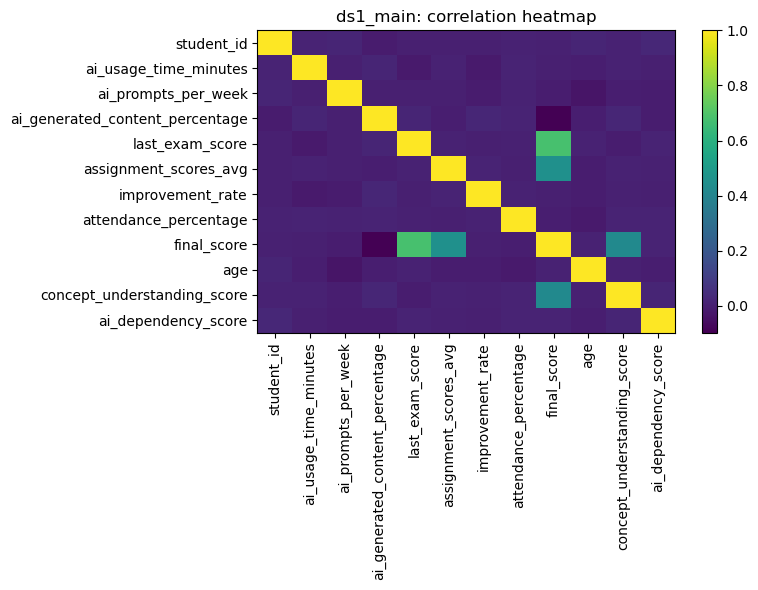

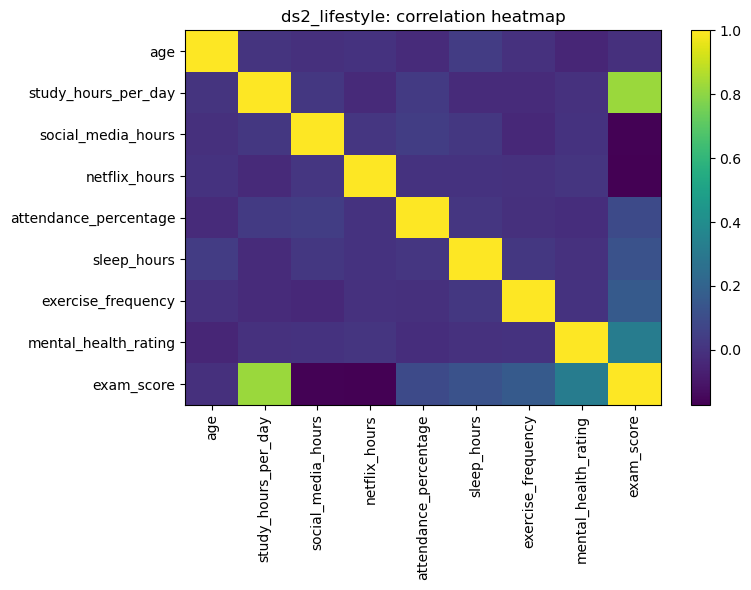

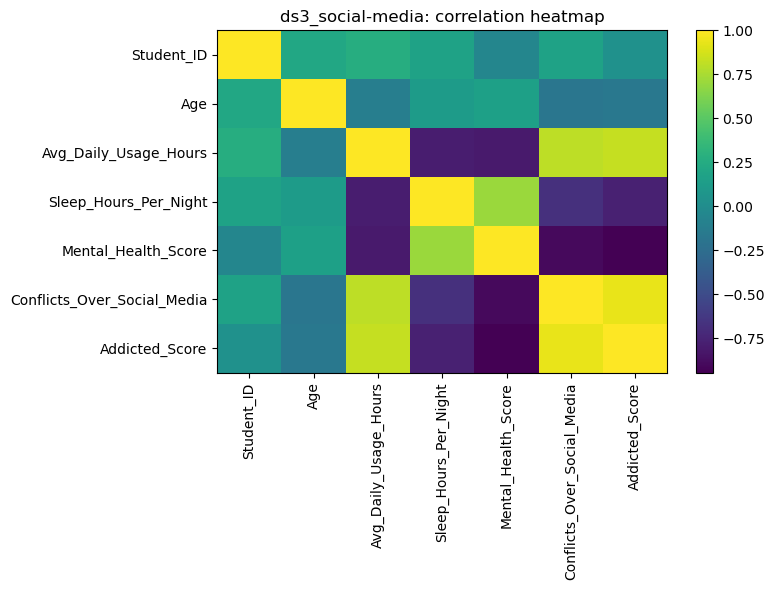

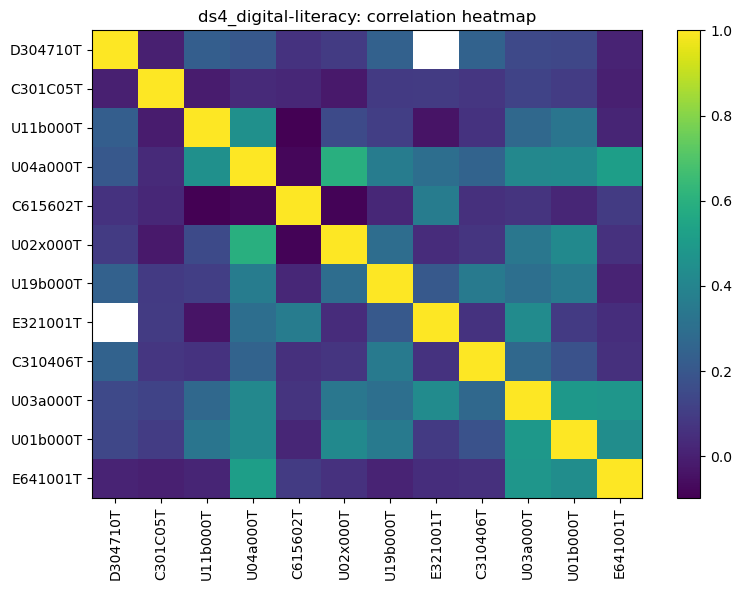

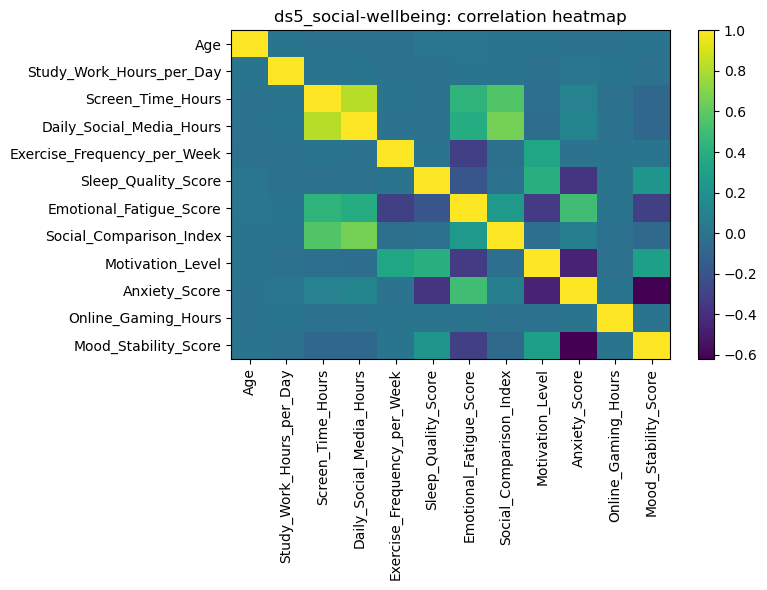

In [9]:
def correlation_plot(df: pd.DataFrame, title: str = "", max_cols: int = 12):
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] < 2:
        print("Not enough numeric columns for correlation plot.")
        return

    if num.shape[1] > max_cols:
        stds = num.std(numeric_only=True).sort_values(ascending=False)
        keep = stds.head(max_cols).index
        num = num[keep]

    corr = num.corr(numeric_only=True)

    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title(title or "Correlation heatmap")
    plt.tight_layout()
    plt.show()

for name, df in dfs.items():
    correlation_plot(df, title=f"{name}: correlation heatmap", max_cols=12)

### What we observed:

#### Dataset 1:
Positive relationships between previous exam score, average exam scores and final score. This is expected and aligns with the idea of consistent academic indicators. We recognise a lack of indicators that are correlated to final score. There is a slight negative correlation between frequency of ai generated content and final score, highlighting potential for further research into th
#### Dataset 2:
Strongest positive correlation between daily study hours and exam scores. Followed by mental health rating > exercise frequency > sleep hours (with exam scores). Daily social media and netflix (entertainment) usage showed a negative correlation. This highlighted the extent of influence that lifestyle indicators and wellbeing may have over academic performance and was our motivation for sourcing Dataset 5 detailing wellbeing factors to possibly enrich our existing datasets.
### Dataset 3:
Strongest positive relationship between daily average social media usage and addiction score. Since addictions have a negative influence on mental health, social media potentially has a bigger impact on  academic performance than initially recognised.
### Dataset 4:
### Dataset 5:
Strongst positive relationship between daily social media usage and screen time. Social comparison has positive correlation with emotional fatigue, which is in turn positvely ralated to anxiety score. There is also a strong negative correlation nbetween motivation level and anxiety score. These patterns suggest the link between academic performance and an extensive range of psychological factors, which we can factor into our analysis later on.




## Data Profiling Evaluation

Through the data profiling steps, we were able to synthesise the next steps for us to take in our data preparation process:
* Missing values that require data cleaning\
* Schema comparisons show that datasets do not share columns that can be merged due to modelling conflicts, suggesting the need for data structuring
* Indication that the test performance is influenced by a combination of various academic indicators, study beehaviour, lifestyle habits and digital wellbeing factors highlight the potential for data enriching steps and feature engineering on top of data structuring